# QF 627 Programming and Computational Finance
## `Py`Day Week `9`: Problem-Sets for Exercise `7` | `RE`view

> Hi, Team. 👋

> The exercise questions ask you to solve three bigger questions. As with our previous exercise problem sets, while answering the questions you will be able to incorporate what you learned in class and consolidate your understanding.

> Enjoy!"🤞

### For standardization of your answers…

> Please execute the lines of code below before you start work on your answers.

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib as mpl

from pandas_datareader import data as pdr

import datetime as dt
import yfinance as yf

> Let's set some print option.

In [2]:
np.set_printoptions(precision = 3)

plt.style.use("ggplot")

mpl.rcParams["axes.grid"] = True
mpl.rcParams["grid.color"] = "grey"
mpl.rcParams["grid.alpha"] = 0.25

mpl.rcParams["axes.facecolor"] = "white"

mpl.rcParams["legend.fontsize"] = 14

## ☝️ <a id = "bookmark">PyDay Week 9</a>👇

## [----------------> Starts Here :)](#yay)

## 👇 <font color = "purple"> Bigger Question 1. 

> Here's something that's familiar to you, with a few minor tweaks.

### Please create a predictive model for the weekly return of AMZN stock. You will use supervised learning for your predictive modelling.

> As you learned in class, to do this it is essential to know what factors are related to Amazon’s stock price, and to incorporate as much information as you can into the model.

> Among the three major factors (correlated assets, technical indicators, and fundamental analysis), you will use correlated assets and technical indicators as features here.

    Step 1. Use 75% of your data for the training of your algorithm, and 25% for the testing set.

    Step 2. For your feature engineering...
    
> Our operational definition of `outcome` (`Y`) is the weekly return of Amazon (AMZN). The number of trading days in a week is assumed to be five, and we compute the return using five trading days. 
<br>
    
* <font color = "green"> NOTE: The lagged five-day variables embed the time series component by using a time-delay approach, where the lagged variable is included as one of the predictor variables. This step translates the time series data into a supervised regression-based model framework.
<br>    
    
> For `input features` (`predictors`; `Xs`), we use (The variables used as predictors are as follows) ...

> `Correlated assets`

* lagged five-day returns of stocks (AAPL, MSFT, F);
* currency exchange rates (USD/JPY and GBP/USD);
* indices (S&P 500, Dow Jones, and VIX);
* lagged five-day, 15-day, 30-day, and 60-day returns of AMZN.

> `Technical indicators`

* 21-day, 63-day, and 252-day moving averages;
* 10-day, 30-day, and 200-day exponential moving averages.

    
    Step 3. For your algorithm of choices, please assess the model performance of the following algorithms: 

* Linear Regression
* Elastic Net
* LASSO
* Support Vector Machine
* K-Nearest Neighbor
* ARIMA
* Decision Tree
* Extra Trees 
* Random Forest
* Gradient Boosting Tree
* Adaptive Boosting
    
    
    Step 4. For this exercise, hyperparameter tuning won’t be requested. 
    
    Step 5. But make sure to compare the model performance of the above algorithms.

> The metric for assessing model performance will be mean squared error (`MSE`).
<br>

> Show which of the algorithms perform relatively better by a comparison visualization of performance, for both the training and testing sets learned in class. 

    Step 6. Using the model of your choice, please visualize the actual vs. predicted (estimated) data.

### Below are the lines of code that lead to an answer:

### <font color = red> Answer 1 is presented in the cell below: </font>

## <a id = "yay"></a>  <font color = "green"> PyDay Week 9 Starts Here :) </font>  [back to table of contents](#bookmark)

## <font color = blue> 👉 Questions 2 to 6 ask you to build, execute, and backtest a trend-following (momentum), using `Relative Strength Index` (`RSI`). </font>

#### The Relative Strength Index (RSI) is an indicator that uses the closing prices of an asset to identify oversold and overbought conditions. 

> Most commonly, RSI is calculated using a 14-day period, and measured on a scale from zero to 100. (It is an oscillator.)

> Traders usually buy an asset when it is oversold (when its RSI is below 30) and sell when it is overbought (when its RSI is above 70). 

> More extreme overbought and oversold levels, such as 80 and 20, are used less frequently, and imply stronger momentum.

#### You are asked to build a trading strategy with the following set of rules.

### <font color = green> NOTE: Apple (`AAPL`) as our security of interest. The `investment horizon` will be three years between 2015 and 2017; your `capital` is USD 100,000; and there is a USD 5 flat `commission fee` per trade.

- You can go long and short.
<br>

- To calculate RSI, use 14 periods (trading days).
<br>

- Enter a long position if RSI crosses the lower threshold (standard value of 30), moving upwards. Exit the position when RSI becomes higher than the middle level (value of 50).
<br>

- Enter a short position if RSI crosses the upper threshold (standard value of 70), moving downwards. Exit the position when RSI becomes less than 50.
<br>

- Only one position can be open at a time.

### <font color = green> NOTE: The RSI is defined as follows:
    
### Calculating the RSI first requires the RS which requires an average value of n-many previous trading days. 
<br>
    
- As discussed, a value of 14 days is common for the RSI calculation. 
<br>
    
- The first RS value requires the price from all 14 of the first trading days. Often, this is a source of confusion with the RSI given successive values only require the most recent. 
   
    
    Step 1. For 14 periods, calculate the difference in price from the current period and the previous period
    
    Step 2. For each period, record each positive change in price as a gain and each negative change as a loss
    
    Step 3. On the 14th period, calculate the arithmetic mean of the gains and losses for the entire 14 day period (e.g. gains / 14 & losses / 14)
    
    Step 4. Use these values to calculate the RS
    
### <center> $ RS = \frac{AverageGain}{AverageLoss} $
    
    Step 5. Use the RS value to calculate the RSI
    
    Step 6. For each proceeding period, use only the previous RSI value to calculate the next average value 
    by multiplying by our lookback period – 1 (e.g., 13 for a lookback of 14).
    
    Step 7. Add the value obtained in Step 6 to the current day’s value (run this for both the gains and losses)
    
### <center> $ RSI = 100 - \frac{100}{1 + RS} $

### Visualize your buy and sell positions.

### Below are the lines of code that lead to an answer:

### IMPORT

In [4]:
data_aapl =\
(
    yf
    .download(["AAPL"],
              start = pd.Timestamp(2015, 1, 1), 
              end = pd.Timestamp(2017, 12, 31)
             )
    ["Adj Close"]
)

data_aapl

[*********************100%%**********************]  1 of 1 completed


Date
2015-01-02    24.373960
2015-01-05    23.687305
2015-01-06    23.689533
2015-01-07    24.021717
2015-01-08    24.944681
                ...    
2017-12-22    41.216572
2017-12-26    40.170925
2017-12-27    40.177979
2017-12-28    40.291031
2017-12-29    39.855335
Name: Adj Close, Length: 755, dtype: float64

## WRANGLE

In [6]:
price_change = data_aapl.diff().iloc[1: ]
price_change

Date
2015-01-05   -0.686655
2015-01-06    0.002228
2015-01-07    0.332184
2015-01-08    0.922964
2015-01-09    0.026754
                ...   
2017-12-22    0.000000
2017-12-26   -1.045647
2017-12-27    0.007053
2017-12-28    0.113052
2017-12-29   -0.435696
Name: Adj Close, Length: 754, dtype: float64

In [14]:
gain = price_change.clip(lower = 0)
loss = -price_change.clip(upper = 0)

gain_loss =\
(
    pd
    .concat([gain, loss],
            axis = 1)
)

In [15]:
gain_loss.iloc[:14].mean(0)

Adj Close    0.218481
Adj Close    0.160358
dtype: float64

In [16]:
g_rs_init, l_rs_init =\
(
    gain_loss
    .iloc[ :14]
    .mean()
    .values
)

rs_init = g_rs_init / l_rs_init

In [17]:
gain_loss.iloc[ : 14]

,Adj Close,Adj Close
Date,,
2015-01-05,0.000000,0.686655
2015-01-06,0.002228,-0.000000
2015-01-07,0.332184,-0.000000
2015-01-08,0.922964,-0.000000
2015-01-09,0.026754,-0.000000
2015-01-12,0.000000,0.615314
2015-01-13,0.216259,-0.000000
2015-01-14,0.000000,0.093641
2015-01-15,0.000000,0.664354


In [9]:
gain_loss.index[13]

Timestamp('2015-01-23 00:00:00')

In [18]:
g_rs = g_rs_init
l_rs = l_rs_init

init_date = gain_loss.index[13]
init_date_plus_1 = gain_loss.index[14]

gl_rs_df =\
(
    pd
    .DataFrame(
        {init_date: [g_rs, l_rs]},
        index = ["gain_rs", "loss_rs"]
    ).T
)

for d, (g, l) in gain_loss.loc[init_date_plus_1: ].iterrows():
    g_rs = ((g_rs * 13) + g) / 14
    l_rs = ((l_rs * 13) + l) / 14
    gl_rs_df.loc[d] = [g_rs, l_rs]

gl_rs_df

,gain_rs,loss_rs
2015-01-23,0.218481,0.160358
2015-01-26,0.204786,0.148904
2015-01-27,0.190158,0.201327
2015-01-28,0.274828,0.186947
2015-01-29,0.312365,0.173593
...,...,...
2017-12-22,0.164144,0.106895
2017-12-26,0.152419,0.173949
2017-12-27,0.142036,0.161524
2017-12-28,0.139966,0.149986


In [19]:
# convert rs to rsi

rs =\
(
    gl_rs_df["gain_rs"]
    /
    gl_rs_df["loss_rs"]
)

rsi = 100 - 100 / (1 + rs) # oscillator running between 0 and 100

In [20]:
rsi

2015-01-23    57.671277
2015-01-26    57.899919
2015-01-27    48.573560
2015-01-28    59.515599
2015-01-29    64.278192
                ...    
2017-12-22    60.560967
2017-12-26    46.701643
2017-12-27    46.790101
2017-12-28    48.271997
2017-12-29    43.270444
Length: 741, dtype: float64

### Detect `RSI` Signals for Buy and Sell

In [21]:
rsi_up =\
(
    rsi
    .diff()
    >
    0
)

rsi_down =\
(
    rsi
    .diff()
    <
    0
)

In [22]:
crossed_70 =\
(
    np
    .sign(
         (rsi - 70) * (rsi - 70).shift(1)
         )
    .fillna(1) == -1
)

crossed_50 = (np.sign((rsi - 50) * (rsi - 50).shift(1))
              .fillna(1) == - 1)

crossed_30 = (np.sign((rsi - 30) * (rsi - 30).shift(1)).fillna(1) == -1)

In [23]:
# Generate trade signals

buy = rsi_up & crossed_30 # signals when RSI crosses 30 upwards
unwind = crossed_50 # EXIT # when RSI returns to 50 (neutral)
sell = rsi_down & crossed_70 # RSI crosses 70 downwards

In [24]:
buy[buy]

2015-07-10    True
2015-08-06    True
2015-08-26    True
2015-12-21    True
2016-01-12    True
2016-05-16    True
2016-11-15    True
dtype: bool

In [25]:
sell[sell]

2015-02-25    True
2016-03-23    True
2016-04-05    True
2016-04-07    True
2016-07-29    True
2016-08-02    True
2016-08-22    True
2016-09-16    True
2017-01-12    True
2017-01-19    True
2017-01-24    True
2017-01-31    True
2017-03-21    True
2017-04-05    True
2017-05-03    True
2017-05-17    True
2017-08-10    True
2017-11-01    True
2017-11-14    True
dtype: bool

In [26]:
position_series =\
(
    pd
    .Series(np.nan)
    .reindex(rsi.index)
)

position_series[buy] = 1
position_series[unwind] = 0
position_series[sell] = -1

position_series.iloc[0] = 0

position_series =\
(
    position_series
    .ffill()
)

position_series.name = "positions"

position_series

2015-01-23    0.0
2015-01-26    0.0
2015-01-27    0.0
2015-01-28    0.0
2015-01-29    0.0
             ... 
2017-12-22    0.0
2017-12-26    0.0
2017-12-27    0.0
2017-12-28    0.0
2017-12-29    0.0
Name: positions, Length: 741, dtype: float64

In [27]:
### Prep. for visualization

buy_unwind = position_series.clip(lower = 0)
buy_once = (buy_unwind.diff() == 1)
unwind_buy = (buy_unwind.diff() == -1)

sell_unwind = position_series.clip(upper = 0)
sell_once = (sell_unwind.diff() == -1)
unwind_sell = (sell_unwind.diff() == 1)

## Predictive model is limited in actual field practice; what we need is `adaptive` model in quantitative finance.

### <font color = red> Answer 2 is presented in the cell below: </font>

### VISUALIZE

In [28]:
%who

buy	 buy_once	 buy_unwind	 crossed_30	 crossed_50	 crossed_70	 d	 data_aapl	 dt	 
g	 g_rs	 g_rs_init	 gain	 gain_loss	 gl_rs_df	 init_date	 init_date_plus_1	 l	 
l_rs	 l_rs_init	 loss	 mpl	 np	 pd	 pdr	 plt	 position_series	 
price_change	 rs	 rs_init	 rsi	 rsi_down	 rsi_up	 sell	 sell_once	 sell_unwind	 
unwind	 unwind_buy	 unwind_sell	 yf	 


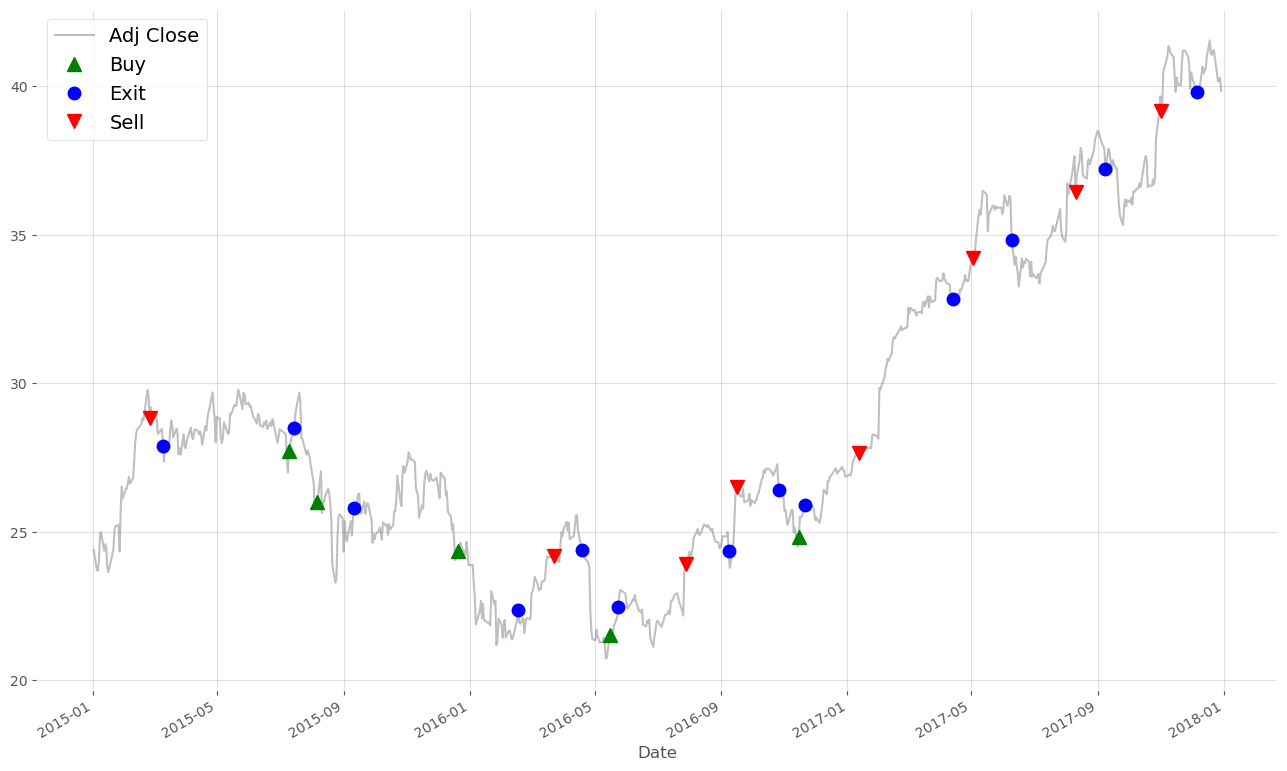

In [74]:
fig, ax1 =\
(
    plt
    .subplots(figsize = [16, 10]
             )
)

data_aapl.plot(ax = ax1,
               color = "grey",
               alpha = 0.50)

aapl_point =\
(
    data_aapl
    .reindex(position_series.index)
)

plt.plot(aapl_point[buy_once], "g^", markersize = 10, label = "Buy")
plt.plot(aapl_point[unwind_sell | unwind_buy], "bo", markersize = 9, label = "Exit")
plt.plot(aapl_point[sell_once], "rv", markersize = 10, label = "Sell")

plt.legend()

### <font color = blue> 👉 Question 3</font>. How much in cumulative returns could you have had as a result of the RSI strategy?

In [32]:
unwind_once = unwind_buy | unwind_sell

buy_once.name = "buy"

unwind_once.name = "exit"

sell_once.name = "sell"

In [33]:
%who

aapl_point	 ax1	 buy	 buy_once	 buy_unwind	 crossed_30	 crossed_50	 crossed_70	 d	 
data_aapl	 dt	 fig	 g	 g_rs	 g_rs_init	 gain	 gain_loss	 gl_rs_df	 
init_date	 init_date_plus_1	 l	 l_rs	 l_rs_init	 loss	 mpl	 np	 pd	 
pdr	 plt	 position_series	 price_change	 rs	 rs_init	 rsi	 rsi_down	 rsi_up	 
sell	 sell_once	 sell_unwind	 unwind	 unwind_buy	 unwind_once	 unwind_sell	 yf	 


In [34]:
to_sim_df =\
(
    pd
    .concat([buy_once, unwind_once, sell_once, data_aapl],
            axis = 1)
    .dropna()
)

to_sim_df

,buy,exit,sell,Adj Close
2015-01-23,False,False,False,25.187691
2015-01-26,False,False,False,25.214437
2015-01-27,False,False,False,24.331606
2015-01-28,False,False,False,25.707134
2015-01-29,False,False,False,26.507490
...,...,...,...,...
2017-12-22,False,False,False,41.216572
2017-12-26,False,False,False,40.170925
2017-12-27,False,False,False,40.177979
2017-12-28,False,False,False,40.291031


In [35]:
## Setup for Your Simulation

init_cap = 100000
position = 0
stock_to_buy = 1000
fee = 5

## Track Your Cash and Position

cash_pos_dict = {}
cap = init_cap

## Simulation Loop ==> A Baseline Intelligence System

for d, (b, u, s, p) in to_sim_df.iterrows():
    if b: # buy signal is detected
        cap -= p * stock_to_buy
        cap -= fee
        position = stock_to_buy # LONG

    if u: 
        cap += p * position
        cap -= fee
        position = 0 # FLAT

    if s:
        cap += p * stock_to_buy
        cap -= fee
        position = -stock_to_buy # SHORT
        
    cash_pos_dict[d] = cap, position

In [36]:
%who

aapl_point	 ax1	 b	 buy	 buy_once	 buy_unwind	 cap	 cash_pos_dict	 crossed_30	 
crossed_50	 crossed_70	 d	 data_aapl	 dt	 fee	 fig	 g	 g_rs	 
g_rs_init	 gain	 gain_loss	 gl_rs_df	 init_cap	 init_date	 init_date_plus_1	 l	 l_rs	 
l_rs_init	 loss	 mpl	 np	 p	 pd	 pdr	 plt	 position	 
position_series	 price_change	 rs	 rs_init	 rsi	 rsi_down	 rsi_up	 s	 sell	 
sell_once	 sell_unwind	 stock_to_buy	 to_sim_df	 u	 unwind	 unwind_buy	 unwind_once	 unwind_sell	 
yf	 


In [39]:
simulated =\
(
    pd
    .DataFrame(cash_pos_dict,
               index = ["capital", "position"]
              )
    .T
)

simulated["position"] = simulated["position"] * data_aapl.iloc[:]

simulated.head(55)

,capital,position
2015-01-23,100000.000000,0.000000
2015-01-26,100000.000000,0.000000
2015-01-27,100000.000000,0.000000
2015-01-28,100000.000000,0.000000
2015-01-29,100000.000000,0.000000
2015-01-30,100000.000000,0.000000
2015-02-02,100000.000000,0.000000
2015-02-03,100000.000000,0.000000
2015-02-04,100000.000000,0.000000
2015-02-05,100000.000000,0.000000


In [40]:
# Total Return Index (TRI)

tri = simulated.sum(1)
tri

2015-01-23    100000.000000
2015-01-26    100000.000000
2015-01-27    100000.000000
2015-01-28    100000.000000
2015-01-29    100000.000000
                  ...      
2017-12-22     93731.783981
2017-12-26     93731.783981
2017-12-27     93731.783981
2017-12-28     93731.783981
2017-12-29     93731.783981
Length: 741, dtype: float64

In [41]:
(
    "{:.2f}%"
    .format((tri[-1] * 100 / tri[0]) - 100)
)

/var/folders/m5/6qjdcqv55y72ghb4rkssq56m0000gn/T/ipykernel_19386/27473338.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  .format((tri[-1] * 100 / tri[0]) - 100)


'-6.27%'

### Below are the lines of code that lead to an answer:

### <font color = red> Answer 3 </font>

    The answer is ____________ % .

### <font color = blue> 👉 Question 4</font>. Now please find the `five` worst drawdown periods over the investment horizon and provide their net drawdown in % and duration, respectively.

### <font color = green> The question asks you to find the five worst drawdown periods, beyond identifying max drawdown (MDD).

### Below are the lines of code that lead to an answer:

In [42]:
tri / tri[0]

/var/folders/m5/6qjdcqv55y72ghb4rkssq56m0000gn/T/ipykernel_19386/264990829.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  tri / tri[0]


2015-01-23    1.000000
2015-01-26    1.000000
2015-01-27    1.000000
2015-01-28    1.000000
2015-01-29    1.000000
                ...   
2017-12-22    0.937318
2017-12-26    0.937318
2017-12-27    0.937318
2017-12-28    0.937318
2017-12-29    0.937318
Length: 741, dtype: float64

In [45]:
def calculate_drawdown_stats(df):
    if df.shape[0] == 1:
        return None

    drawdown_value = df.iloc[ : , 1]

    series_d =\
        {
            "Date": df["Date"].min(), # starting point of drawdown period
            "Drawdown Length (Days)": df["Date"].max() - df["Date"].min(), # calendar days
            "Drawdown Length (Business Days)": pd.Timedelta(df.count().iloc[0] - 1, "d"), # business days
            "Max Drawdown (%)": drawdown_value.min() * 100 # min. value of drawdown in percentage
        }
    
    return pd.Series(series_d) 

In [46]:
def obtain_drawdown(series):
    
    series.index = series.index.set_names("Date")
    
    return (series / series.cummax()) - 1 
    # as a result, team, 
    # we will have negative values when your series is below its previous peak

In [43]:
def analyze_drawdown(drawdown_series):

    drawdown_df = pd.DataFrame(drawdown_series)

    drawdown_df["drawdown_period_group"] = (drawdown == 0).cumsum()

    drawdown_stats_groupby =\
    (
        drawdown_df
        .reset_index()
        .groupby("drawdown_period_group")
    )

    drawdown_stats =\
    (
        drawdown_stats_groupby
        .apply(calculate_drawdown_stats)
    )

    drawdown_stats = drawdown_stats.dropna().set_index(["Date"])

    return drawdown_stats # index --> time-series ("Date"); three columns () 

In [47]:
drawdown = obtain_drawdown(tri)

In [48]:
drawdown_analyzed = analyze_drawdown(drawdown)

/var/folders/m5/6qjdcqv55y72ghb4rkssq56m0000gn/T/ipykernel_19386/943676594.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  drawdown_stats_groupby


In [49]:
type(drawdown_analyzed)

pandas.core.frame.DataFrame

In [50]:
drawdown_analyzed.columns

Index(['Drawdown Length (Days)', 'Drawdown Length (Business Days)',
       'Max Drawdown (%)'],
      dtype='object')

In [51]:
drawdown_analyzed\
    .sort_values('Max Drawdown (%)')

,Drawdown Length (Days),Drawdown Length (Business Days),Max Drawdown (%)
Date,,,
2015-08-10,872 days,603 days,-10.297436
2015-02-24,2 days,2 days,-0.369830
2015-02-27,5 days,3 days,-0.201296
2015-03-05,4 days,2 days,-0.162526
2015-07-13,1 days,1 days,-0.011080
2015-07-09,1 days,1 days,-0.004953
2015-08-05,1 days,1 days,-0.004915


### <font color = red> Answer 4 </font>

    The Worst drawdown period     : Net drawdown ____________ % | Duration ____________ Days
    
    The 2nd worst drawdown period : Net drawdown ____________ % | Duration ____________ Days
     
    The 3rd worst drawdown period : Net drawdown ____________ % | Duration ____________ Days
         
    The 4th worst drawdown period : Net drawdown ____________ % | Duration ____________ Days
    
    The 5th worst drawdown period : Net drawdown ____________ % | Duration ____________ Days

### <font color = blue> 👉 Question 5</font>. Within the investment horizon, please calculate annual returns for each of the three years and then find the year that performs better than average vs. less than average annual returns.

### Below are the lines of code that lead to an answer:

In [53]:
tri_df = tri.to_frame()

In [55]:
tri_df["year"]=\
(
    tri_df
    .index
    .year
)

In [57]:
tri_df.columns = ["tri", "year"]

In [59]:
yearly_returns =\
(
    tri_df
    .groupby("year")
    ["tri"]
    .apply(lambda x: (x.iloc[-1]/ x.iloc[0]) - 1)
)

yearly_returns

year
2015    0.010415
2016   -0.000877
2017   -0.071717
Name: tri, dtype: float64

In [60]:
yearly_returns.mean()

-0.020726306950810496

### <font color = red> Answer 5 </font>

    Below average year(s) : ____________ 
    
    Above average year(s) : ____________ 
     

###  <font color = blue> 👉 Question 6. </font> What's the annualized Sharpe ratio of the current investment strategy?

### Below are the lines of code that lead to an answer:

In [63]:
(tri.pct_change().mean() / tri.pct_change().std()) * ((252/tri.shape[0]) ** 0.5)

-0.01903374761854414

### <font color = red> Answer 6 </font>
    
    Sharpe ratio: __________
    

## 👇 <font color = "purple"> Bigger Question 7. ### 

### This bigger question is where you will execute a principal component analysis (PCA) based portfolio for asset allocation. 
<br>
    
### Go to [the list of SP 500 companies on Wikipedia](https://en.wikipedia.org/wiki/List_of_S%26P_500_companies).
    
    Step 1: Among the securities added to the S&P 500 component before January 2000, select the first 30 stocks. 
    
    Step 2: Your objective is to find the portfolio using PCA. Using what you learned in class, 
    identify the profile of each portfolio. 
    
    Step 3: Then backtest the performance of your portfolio, relative to the equal weight portfolio. 
    Here, as you learned in class, use 80% of your data for PCA and 20% for backtesting.
    
### <font color = "green"> NOTE: The investment horizon will be 20 years between 2000 and 2019    

### Below are the lines of code that lead to an answer:

### <font color = red> Answer 7 is presented in the cell below: </font>

> 💯 “Thank you for putting your efforts into the individual assessment questions” 😊